# TabResNet DLBAC — evaluation sur tous les jeux

Ce notebook entraîne et évalue **TabResNetDLBAC** sur les **11 jeux DLBAC** entraînables :

- **Synthétiques u4k/u5k/u6k** (mode `instance` : TabResNet + DR-Net + CF binaire)
- **Amazon 1/2/3** (mode `bipolar_hyper` : encodeur + hyperréseau + règles)

**Métriques rapportées** : accuracy, balanced accuracy, AUROC, F1 (macro/micro/weighted), log-loss, matrice de confusion, validité CF (native + harmonisée), nombre de règles, exemples de règles et contrefactuels.

**Courbes d'apprentissage** : loss et accuracy **train vs validation** (max 40 epochs, sans AUROC).

**Prérequis** : environnement `hyconex`, cache one-hot (`data/dlbac_prepared/onehot_cache/`).

> Amazon ~15–20 min/GPU chacun ; synthétiques ~5–15 min chacun.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

warnings.filterwarnings("ignore", category=UserWarning)

_cwd = Path.cwd().resolve()
ROOT = None
for p in (_cwd, _cwd.parent):
    if (p / "prepare_dlbac_datasets.py").is_file():
        ROOT = p
        break
if ROOT is None:
    raise FileNotFoundError("Ouvrez depuis HyConEx_from_scratch/ ou notebooks/")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import importlib
import train_tabresnet_dlbac as _train_mod
importlib.reload(_train_mod)

from eval_cf_harmonized_dlbac import eval_all_targets, eval_random_target, load_tabresnet as load_cf_backend
from prepare_dlbac_datasets import discover_dlbac_datasets, format_rule
from tabresnet_dlbac.eval_utils import compute_classification_metrics, load_trainer_from_checkpoint
from train_nouveau_module_dlbac_quantile import build_onehot_splits
from train_tabresnet_dlbac import (
    RESULTS_DIR,
    collect_training_history,
    config_for_dataset,
    discover_specs,
    train_one,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ALL_SPECS = {s.name: s for s in discover_specs()}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Jeux entraînables ({len(ALL_SPECS)}):", sorted(ALL_SPECS.keys()))
print(f"Device: {DEVICE}")
print(f"Résultats: {RESULTS_DIR}")

Jeux entraînables (11): ['amazon1', 'amazon2', 'amazon3', 'u4k-r4k-auth11k', 'u4k-r4k-auth21k', 'u4k-r4k-auth22k', 'u4k-r6k-auth28k', 'u4k-r7k-auth20k', 'u5k-r5k-auth12k', 'u5k-r5k-auth19k', 'u6k-r6k-auth32k']
Device: cuda
Résultats: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\tabresnet_dlbac


## Configuration

| Variable | Description |
|----------|-------------|
| `DATASETS` | `None` = tous ; ou ex. `["u4k-r4k-auth11k", "amazon1"]` |
| `RETRAIN` | `True` = ré-entraîne même si JSON existe |
| `BACKFILL_MISSING_HISTORY` | `True` = ré-entraîne les jeux sans fichier `*_history.json` pour les courbes |
| `PLOT_EACH_DATASET` | Affiche la courbe après chaque jeu |
| `SKIP_AMAZON` | `True` = synthétiques uniquement (rapide) |
| `COMPUTE_CF_HARMONIZED` | Protocoles CF harmonisés (random + all targets) |
| `MAX_CF_SAMPLES` | Sous-échantillon pour l'éval CF harmonisée |

In [2]:
MAX_LEARNING_EPOCHS = 40

DATASETS = None
RETRAIN = False
SKIP_AMAZON = False
VERBOSE = True
COMPUTE_CF_HARMONIZED = True
MAX_CF_SAMPLES = 800
# Si True : ré-entraîne les jeux dont l'historique manque (courbes d'apprentissage)
BACKFILL_MISSING_HISTORY = True
# Affiche une courbe immédiatement après chaque jeu entraîné / backfillé
PLOT_EACH_DATASET = True

names = sorted(ALL_SPECS.keys()) if DATASETS is None else list(DATASETS)
if SKIP_AMAZON:
    names = [n for n in names if not n.startswith("amazon")]
print("Jeux sélectionnés:", names)

Jeux sélectionnés: ['amazon1', 'amazon2', 'amazon3', 'u4k-r4k-auth11k', 'u4k-r4k-auth21k', 'u4k-r4k-auth22k', 'u4k-r6k-auth28k', 'u4k-r7k-auth20k', 'u5k-r5k-auth12k', 'u5k-r5k-auth19k', 'u6k-r6k-auth32k']


In [3]:
def history_dataframe(name: str, history: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame(history).copy().head(MAX_LEARNING_EPOCHS)
    df["dataset"] = name
    df["step"] = np.arange(1, len(df) + 1)
    if "phase" not in df.columns:
        df["phase"] = "train"
    else:
        df["phase"] = df["phase"].fillna("train")
    return df


def _loss_series(df: pd.DataFrame) -> tuple[pd.Series, pd.Series | None]:
    train = df["train_loss_ce"] if "train_loss_ce" in df.columns else df["train_loss"]
    val = df["val_loss"] if "val_loss" in df.columns else None
    return train, val


def plot_dataset_learning_curves(ax_loss, ax_acc, name: str, history: list[dict], *, row_meta: dict | None = None) -> None:
    df = history_dataframe(name, history)
    mode = (row_meta or {}).get("mode", "?")
    train_loss, val_loss = _loss_series(df)

    ax_loss.plot(df["step"], train_loss, color="#1f77b4", linewidth=1.8, label="train")
    if val_loss is not None and val_loss.notna().any():
        ax_loss.plot(df["step"], val_loss, color="#d62728", linewidth=1.8, label="val")
    ax_loss.set_ylabel("loss (CE)")
    ax_loss.set_xlabel("epoch")
    ax_loss.legend(loc="upper right", fontsize=7)
    ax_loss.grid(True, alpha=0.25)

    if "train_accuracy" in df.columns and df["train_accuracy"].notna().any():
        ax_acc.plot(df["step"], df["train_accuracy"], color="#1f77b4", linewidth=1.8, label="train")
    if "val_accuracy" in df.columns and df["val_accuracy"].notna().any():
        ax_acc.plot(df["step"], df["val_accuracy"], color="#d62728", linewidth=1.8, label="val")
    ax_acc.set_ylabel("accuracy")
    ax_acc.set_xlabel("epoch")
    ax_acc.set_ylim(0.0, 1.02)
    ax_acc.legend(loc="lower right", fontsize=7)
    ax_acc.grid(True, alpha=0.25)

    if df["phase"].nunique() > 1:
        for i in range(1, len(df)):
            if df.iloc[i]["phase"] != df.iloc[i - 1]["phase"]:
                ax_loss.axvline(df.iloc[i]["step"], color="gray", linestyle=":", alpha=0.5)
                ax_acc.axvline(df.iloc[i]["step"], color="gray", linestyle=":", alpha=0.5)

    title = f"{name} ({mode})"
    ax_loss.set_title(f"{title} — loss", fontsize=10)
    ax_acc.set_title(f"{title} — accuracy", fontsize=10)


def show_single_learning_curve(name: str, history: list[dict], row_meta: dict | None = None) -> None:
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 4))
    plot_dataset_learning_curves(ax_loss, ax_acc, name, history, row_meta=row_meta)
    plt.tight_layout()
    plt.show()


def plot_all_learning_curves(histories: dict[str, list[dict]], rows_by_name: dict[str, dict]) -> None:
    if not histories:
        print("Aucun historique disponible.")
        return

    ordered = [n for n in names if n in histories]
    n = len(ordered)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    for metric_title, suffix in [("Loss train vs val", "loss"), ("Accuracy train vs val", "acc")]:
        fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.6 * nrows), squeeze=False)
        for ax, ds_name in zip(axes.ravel(), ordered):
            df = history_dataframe(ds_name, histories[ds_name])
            mode = rows_by_name.get(ds_name, {}).get("mode", "?")
            train_loss, val_loss = _loss_series(df)
            if suffix == "loss":
                ax.plot(df["step"], train_loss, color="#1f77b4", linewidth=1.8, label="train")
                if val_loss is not None and val_loss.notna().any():
                    ax.plot(df["step"], val_loss, color="#d62728", linewidth=1.8, label="val")
                ax.set_ylabel("loss (CE)")
                ax.set_title(f"{ds_name} ({mode})", fontsize=9)
            else:
                if "train_accuracy" in df.columns:
                    ax.plot(df["step"], df["train_accuracy"], color="#1f77b4", linewidth=1.8, label="train")
                if "val_accuracy" in df.columns:
                    ax.plot(df["step"], df["val_accuracy"], color="#d62728", linewidth=1.8, label="val")
                ax.set_ylabel("accuracy")
                ax.set_ylim(0, 1.02)
                ax.set_title(f"{ds_name} ({mode})", fontsize=9)
            ax.set_xlabel("epoch")
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.25)
        for ax in axes.ravel()[n:]:
            ax.axis("off")
        fig.suptitle(f"TabResNet DLBAC — {metric_title} (max {MAX_LEARNING_EPOCHS} epochs)", fontsize=13)
        plt.tight_layout()
        out_path = RESULTS_DIR / f"learning_curves_{suffix}.png"
        fig.savefig(out_path, dpi=140, bbox_inches="tight")
        print(f"Figure sauvegardée : {out_path}")
        plt.show()

## Entraînement (avec cache JSON + checkpoints)

[cache] amazon1


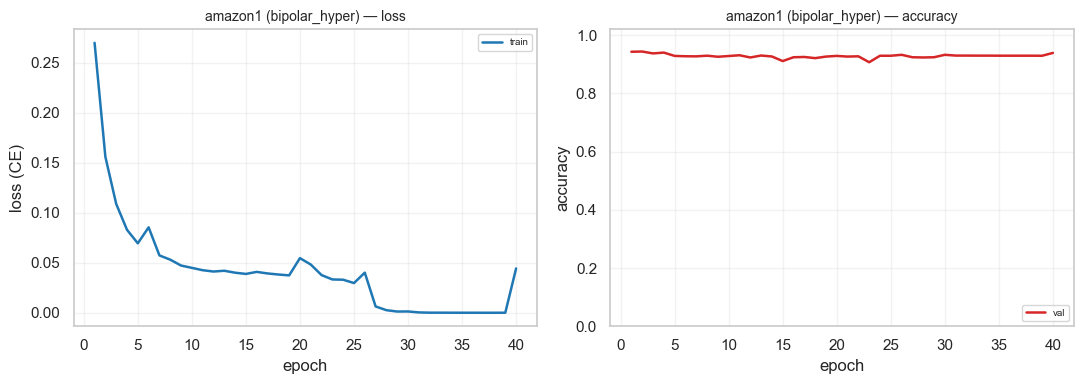

  [PASS] mode=bipolar_hyper auroc=0.8573 acc=0.9457 cf=1.0000 rules=48
[cache] amazon2


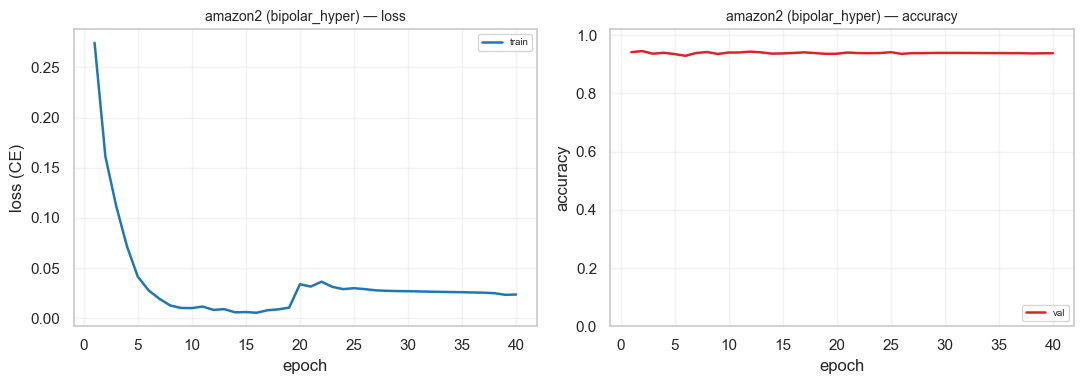

  [PASS] mode=bipolar_hyper auroc=0.8274 acc=0.9463 cf=1.0000 rules=48
[cache] amazon3


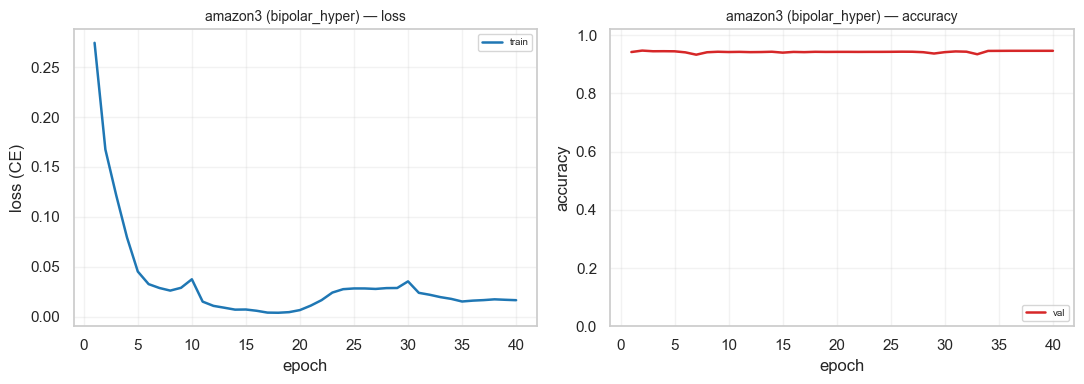

  [PASS] mode=bipolar_hyper auroc=0.8281 acc=0.9466 cf=1.0000 rules=48
[cache] u4k-r4k-auth11k
  [history] entraînement pour courbes — u4k-r4k-auth11k ...

=== u4k-r4k-auth11k (historique) ===
  Strategie: TabResNet instance (HybridDRNetModel)
[Epoch 001/25] loss=2.2270 val_acc=0.7738 val_auroc=0.9853 best(accuracy)=0.7738
[Epoch 002/25] loss=0.9037 val_acc=0.9037 val_auroc=0.9968 best(accuracy)=0.9037
[Epoch 003/25] loss=0.6996 val_acc=0.9293 val_auroc=0.9985 best(accuracy)=0.9293
[Epoch 004/25] loss=0.6069 val_acc=0.9499 val_auroc=0.9991 best(accuracy)=0.9499
[Epoch 005/25] loss=0.5660 val_acc=0.9567 val_auroc=0.9993 best(accuracy)=0.9567
[Epoch 006/25] loss=0.5392 val_acc=0.9721 val_auroc=0.9994 best(accuracy)=0.9721
[Epoch 007/25] loss=0.5262 val_acc=0.9533 val_auroc=0.9993 best(accuracy)=0.9721
[Epoch 008/25] loss=0.5088 val_acc=0.9675 val_auroc=0.9996 best(accuracy)=0.9721
[Epoch 009/25] loss=0.4942 val_acc=0.9692 val_auroc=0.9995 best(accuracy)=0.9721
[Epoch 010/25] loss=0.4911 

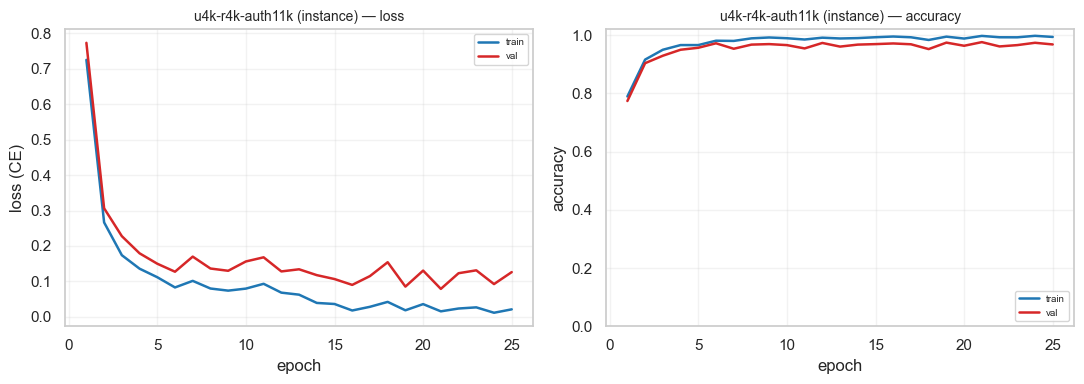

  [PASS] mode=instance auroc=0.9995 acc=0.9735 cf=0.0602 rules=128
[cache] u4k-r4k-auth21k
  [history] entraînement pour courbes — u4k-r4k-auth21k ...

=== u4k-r4k-auth21k (historique) ===
  Strategie: TabResNet instance (HybridDRNetModel)
[Epoch 001/25] loss=2.2550 val_acc=0.4838 val_auroc=0.9511 best(accuracy)=0.4838
[Epoch 002/25] loss=1.3651 val_acc=0.6127 val_auroc=0.9730 best(accuracy)=0.6127
[Epoch 003/25] loss=1.1589 val_acc=0.7161 val_auroc=0.9842 best(accuracy)=0.7161
[Epoch 004/25] loss=1.0579 val_acc=0.7081 val_auroc=0.9843 best(accuracy)=0.7161
[Epoch 005/25] loss=0.9747 val_acc=0.7534 val_auroc=0.9871 best(accuracy)=0.7534
[Epoch 006/25] loss=0.9237 val_acc=0.7849 val_auroc=0.9893 best(accuracy)=0.7849
[Epoch 007/25] loss=0.9000 val_acc=0.7805 val_auroc=0.9897 best(accuracy)=0.7849
[Epoch 008/25] loss=0.8665 val_acc=0.7873 val_auroc=0.9889 best(accuracy)=0.7873
[Epoch 009/25] loss=0.7346 val_acc=0.7897 val_auroc=0.9897 best(accuracy)=0.7897
[Epoch 010/25] loss=0.5593 val_

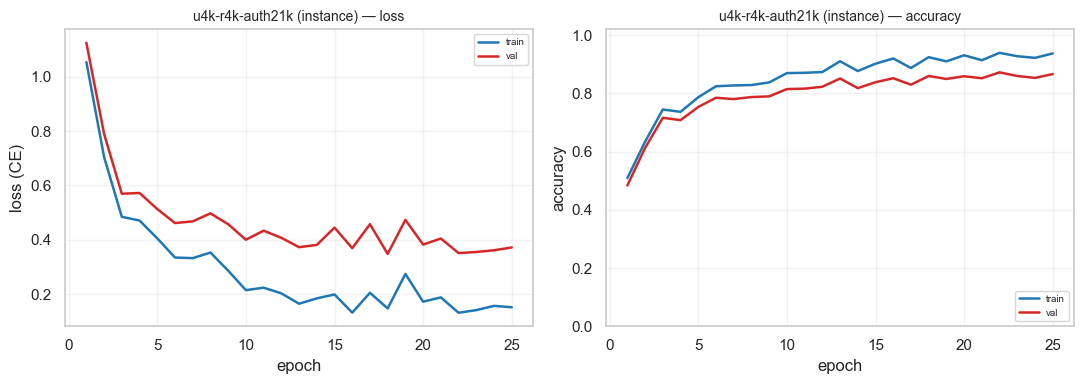

  [PASS] mode=instance auroc=0.9940 acc=0.8672 cf=0.0443 rules=128
[cache] u4k-r4k-auth22k
  [history] entraînement pour courbes — u4k-r4k-auth22k ...

=== u4k-r4k-auth22k (historique) ===
  Strategie: TabResNet instance (HybridDRNetModel)
[Epoch 001/25] loss=2.4523 val_acc=0.3251 val_auroc=0.9224 best(accuracy)=0.3251
[Epoch 002/25] loss=1.6713 val_acc=0.4626 val_auroc=0.9517 best(accuracy)=0.4626
[Epoch 003/25] loss=1.4593 val_acc=0.5202 val_auroc=0.9617 best(accuracy)=0.5202
[Epoch 004/25] loss=1.3350 val_acc=0.5219 val_auroc=0.9643 best(accuracy)=0.5219
[Epoch 005/25] loss=1.2648 val_acc=0.5941 val_auroc=0.9694 best(accuracy)=0.5941
[Epoch 006/25] loss=1.2025 val_acc=0.6123 val_auroc=0.9704 best(accuracy)=0.6123
[Epoch 007/25] loss=1.1590 val_acc=0.5908 val_auroc=0.9701 best(accuracy)=0.6123
[Epoch 008/25] loss=1.1148 val_acc=0.6176 val_auroc=0.9710 best(accuracy)=0.6176
[Epoch 009/25] loss=1.0145 val_acc=0.6043 val_auroc=0.9714 best(accuracy)=0.6176
[Epoch 010/25] loss=0.8179 val_

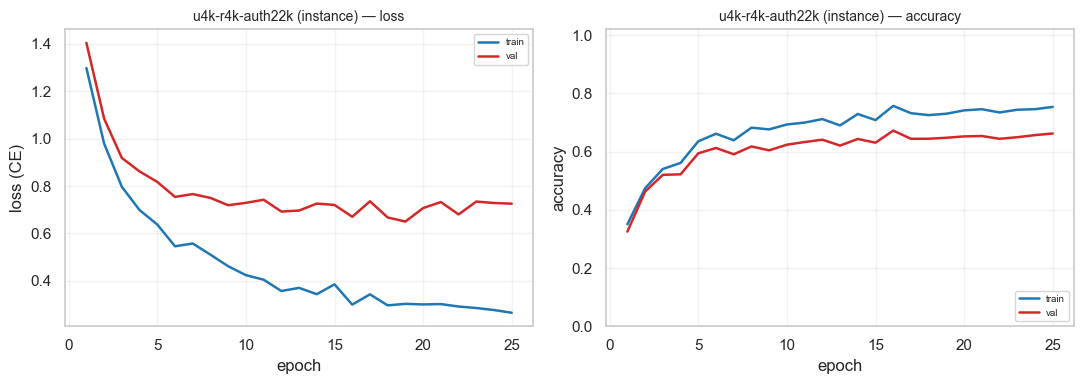

  [PASS] mode=instance auroc=0.9770 acc=0.6608 cf=0.0606 rules=128
[cache] u4k-r6k-auth28k
  [history] entraînement pour courbes — u4k-r6k-auth28k ...

=== u4k-r6k-auth28k (historique) ===
  Strategie: TabResNet instance (HybridDRNetModel)
[Epoch 001/25] loss=2.1448 val_acc=0.5723 val_auroc=0.9563 best(accuracy)=0.5723
[Epoch 002/25] loss=1.2955 val_acc=0.6677 val_auroc=0.9712 best(accuracy)=0.6677
[Epoch 003/25] loss=1.1630 val_acc=0.6981 val_auroc=0.9776 best(accuracy)=0.6981
[Epoch 004/25] loss=1.0779 val_acc=0.7227 val_auroc=0.9809 best(accuracy)=0.7227
[Epoch 005/25] loss=1.0184 val_acc=0.7268 val_auroc=0.9826 best(accuracy)=0.7268
[Epoch 006/25] loss=0.9773 val_acc=0.7509 val_auroc=0.9840 best(accuracy)=0.7509
[Epoch 007/25] loss=0.8050 val_acc=0.7572 val_auroc=0.9853 best(accuracy)=0.7572
[Epoch 008/25] loss=0.7134 val_acc=0.7666 val_auroc=0.9864 best(accuracy)=0.7666
[Epoch 009/25] loss=0.6578 val_acc=0.7755 val_auroc=0.9871 best(accuracy)=0.7755
[Epoch 010/25] loss=0.6234 val_

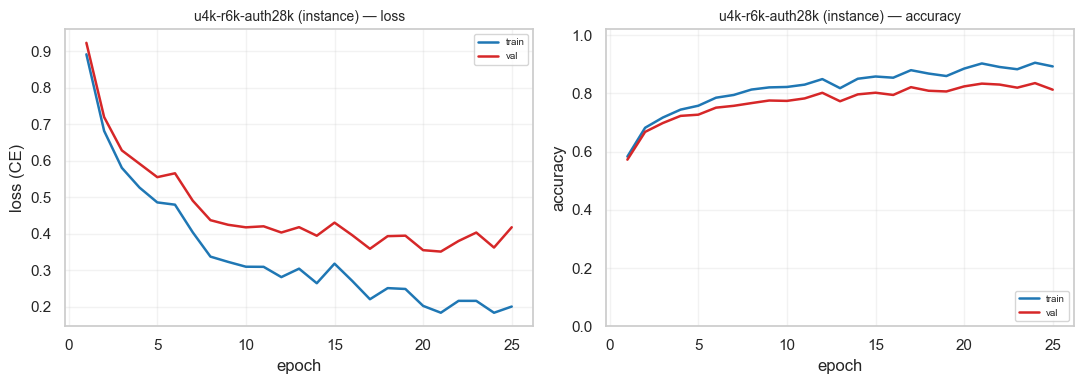

  [PASS] mode=instance auroc=0.9904 acc=0.8336 cf=0.0543 rules=128
[cache] u4k-r7k-auth20k
  [history] entraînement pour courbes — u4k-r7k-auth20k ...

=== u4k-r7k-auth20k (historique) ===
  Strategie: TabResNet instance (HybridDRNetModel)
[Epoch 001/25] loss=2.0572 val_acc=0.7221 val_auroc=0.9775 best(accuracy)=0.7221
[Epoch 002/25] loss=0.9750 val_acc=0.8060 val_auroc=0.9895 best(accuracy)=0.8060
[Epoch 003/25] loss=0.8251 val_acc=0.8325 val_auroc=0.9919 best(accuracy)=0.8325
[Epoch 004/25] loss=0.7477 val_acc=0.8387 val_auroc=0.9933 best(accuracy)=0.8387
[Epoch 005/25] loss=0.7166 val_acc=0.8568 val_auroc=0.9939 best(accuracy)=0.8568
[Epoch 006/25] loss=0.6765 val_acc=0.8731 val_auroc=0.9948 best(accuracy)=0.8731
[Epoch 007/25] loss=0.6604 val_acc=0.8238 val_auroc=0.9933 best(accuracy)=0.8731
[Epoch 008/25] loss=0.6163 val_acc=0.8765 val_auroc=0.9946 best(accuracy)=0.8765
[Epoch 009/25] loss=0.4978 val_acc=0.8833 val_auroc=0.9951 best(accuracy)=0.8833
[Epoch 010/25] loss=0.3937 val_

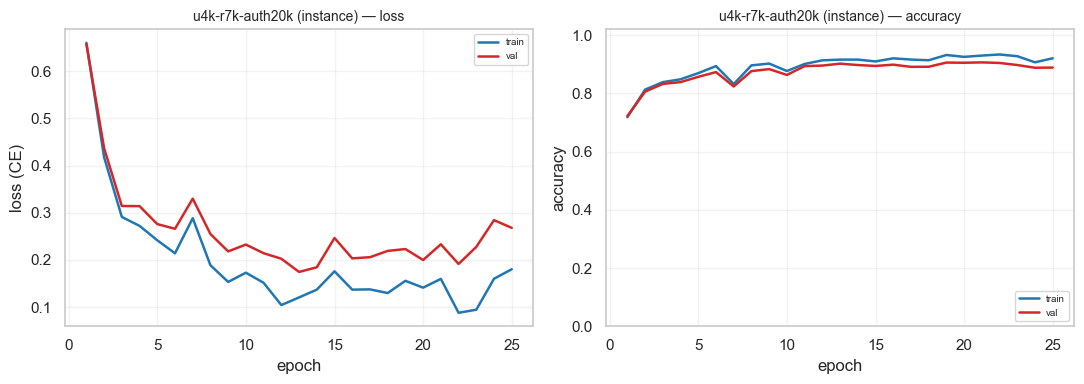

  [PASS] mode=instance auroc=0.9944 acc=0.8909 cf=0.0126 rules=128
[cache] u5k-r5k-auth12k
  [history] entraînement pour courbes — u5k-r5k-auth12k ...

=== u5k-r5k-auth12k (historique) ===
  Strategie: TabResNet instance (HybridDRNetModel)
[Epoch 001/25] loss=2.0885 val_acc=0.7814 val_auroc=0.9903 best(accuracy)=0.7814
[Epoch 002/25] loss=0.8147 val_acc=0.9508 val_auroc=0.9991 best(accuracy)=0.9508
[Epoch 003/25] loss=0.5922 val_acc=0.9621 val_auroc=0.9996 best(accuracy)=0.9621
[Epoch 004/25] loss=0.5337 val_acc=0.9429 val_auroc=0.9995 best(accuracy)=0.9621
[Epoch 005/25] loss=0.5129 val_acc=0.9788 val_auroc=0.9996 best(accuracy)=0.9788
[Epoch 006/25] loss=0.4911 val_acc=0.9813 val_auroc=0.9998 best(accuracy)=0.9813
[Epoch 007/25] loss=0.4818 val_acc=0.9808 val_auroc=0.9998 best(accuracy)=0.9813
[Epoch 008/25] loss=0.4714 val_acc=0.9808 val_auroc=0.9998 best(accuracy)=0.9813
[Epoch 009/25] loss=0.4625 val_acc=0.9887 val_auroc=0.9999 best(accuracy)=0.9887
[Epoch 010/25] loss=0.4484 val_

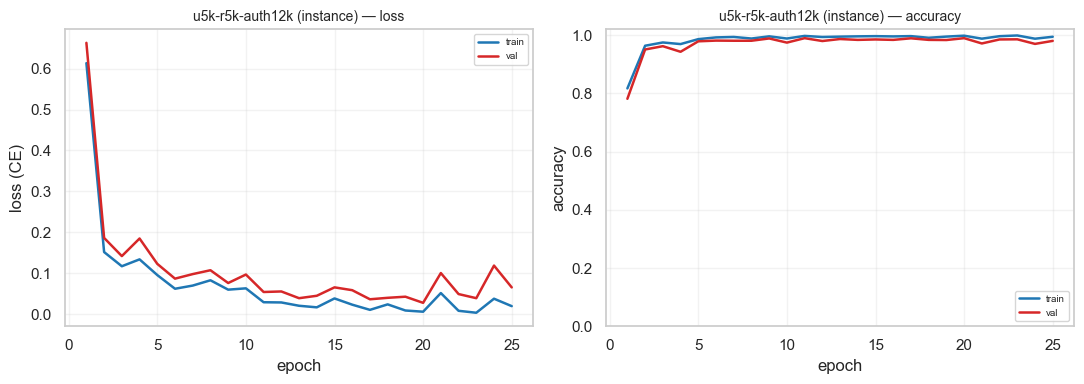

  [PASS] mode=instance auroc=0.9999 acc=0.9913 cf=0.0443 rules=128
[cache] u5k-r5k-auth19k
  [history] entraînement pour courbes — u5k-r5k-auth19k ...

=== u5k-r5k-auth19k (historique) ===
  Strategie: TabResNet instance (HybridDRNetModel)
[Epoch 001/25] loss=2.0642 val_acc=0.6759 val_auroc=0.9785 best(accuracy)=0.6759
[Epoch 002/25] loss=0.9907 val_acc=0.7722 val_auroc=0.9900 best(accuracy)=0.7722
[Epoch 003/25] loss=0.8471 val_acc=0.8263 val_auroc=0.9934 best(accuracy)=0.8263
[Epoch 004/25] loss=0.7923 val_acc=0.8273 val_auroc=0.9935 best(accuracy)=0.8273
[Epoch 005/25] loss=0.7521 val_acc=0.8656 val_auroc=0.9948 best(accuracy)=0.8656
[Epoch 006/25] loss=0.7372 val_acc=0.8618 val_auroc=0.9944 best(accuracy)=0.8656
[Epoch 007/25] loss=0.7254 val_acc=0.8765 val_auroc=0.9950 best(accuracy)=0.8765
[Epoch 008/25] loss=0.6744 val_acc=0.8839 val_auroc=0.9952 best(accuracy)=0.8839
[Epoch 009/25] loss=0.5118 val_acc=0.8730 val_auroc=0.9950 best(accuracy)=0.8839
[Epoch 010/25] loss=0.4338 val_

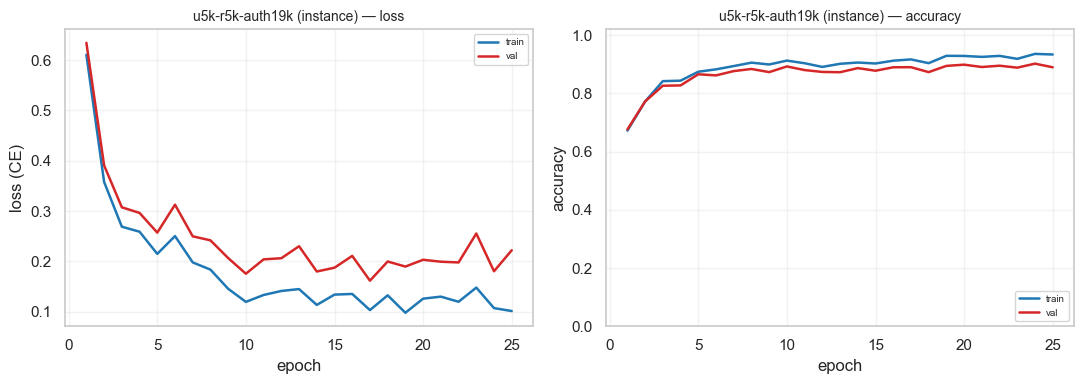

  [PASS] mode=instance auroc=0.9956 acc=0.9017 cf=0.0441 rules=128
[cache] u6k-r6k-auth32k
  [history] entraînement pour courbes — u6k-r6k-auth32k ...

=== u6k-r6k-auth32k (historique) ===
  Strategie: TabResNet instance (HybridDRNetModel)
[Epoch 001/25] loss=1.9175 val_acc=0.6432 val_auroc=0.9729 best(accuracy)=0.6432
[Epoch 002/25] loss=1.1097 val_acc=0.7645 val_auroc=0.9874 best(accuracy)=0.7645
[Epoch 003/25] loss=0.9783 val_acc=0.7937 val_auroc=0.9910 best(accuracy)=0.7937
[Epoch 004/25] loss=0.9057 val_acc=0.8290 val_auroc=0.9941 best(accuracy)=0.8290
[Epoch 005/25] loss=0.8482 val_acc=0.8443 val_auroc=0.9950 best(accuracy)=0.8443
[Epoch 006/25] loss=0.7224 val_acc=0.8357 val_auroc=0.9946 best(accuracy)=0.8443
[Epoch 007/25] loss=0.6177 val_acc=0.8576 val_auroc=0.9956 best(accuracy)=0.8576
[Epoch 008/25] loss=0.6137 val_acc=0.8505 val_auroc=0.9952 best(accuracy)=0.8576
[Epoch 009/25] loss=0.6425 val_acc=0.8747 val_auroc=0.9968 best(accuracy)=0.8747
[Epoch 010/25] loss=0.5758 val_

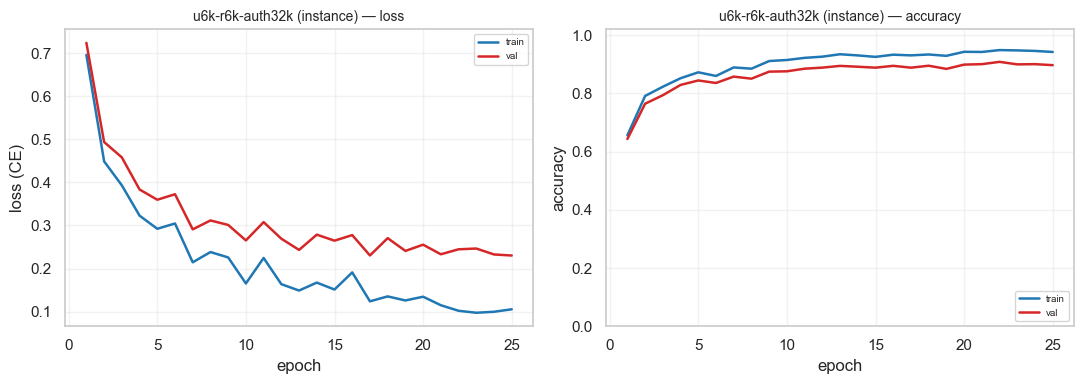

  [PASS] mode=instance auroc=0.9970 acc=0.9035 cf=0.0601 rules=128

11 jeux traités, 11 courbes d'apprentissage disponibles.


In [4]:
rows: list[dict] = []
histories: dict[str, list[dict]] = {}


def _load_training_history(name: str, row: dict) -> list[dict] | None:
    if row.get("training_history"):
        return row["training_history"]
    hist_path = RESULTS_DIR / f"{name}_history.json"
    if hist_path.is_file():
        return json.loads(hist_path.read_text(encoding="utf-8"))
    return None


for name in names:
    json_path = RESULTS_DIR / f"{name}_results.json"
    need_train = RETRAIN or not json_path.is_file()

    if need_train:
        print(f"[train] {name} ...")
        row = train_one(ALL_SPECS[name], save_dir=RESULTS_DIR, verbose=VERBOSE)
        json_path.write_text(json.dumps(row, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
    else:
        row = json.loads(json_path.read_text(encoding="utf-8"))
        print(f"[cache] {name}")

    hist = _load_training_history(name, row)
    if hist is None and BACKFILL_MISSING_HISTORY:
        print(f"  [history] entraînement pour courbes — {name} ...")
        hist = collect_training_history(ALL_SPECS[name], save_dir=RESULTS_DIR, verbose=VERBOSE)
        row["training_history"] = hist
        row["history_file"] = str(RESULTS_DIR / f"{name}_history.json")

    if hist:
        histories[name] = hist
        if PLOT_EACH_DATASET:
            show_single_learning_curve(name, hist, row_meta=row)
    else:
        print(f"  [warn] pas d'historique pour {name}")

    flag = "PASS" if row.get("acceptable") else "FAIL"
    print(
        f"  [{flag}] mode={row['mode']} auroc={row.get('test_auroc', 0):.4f} "
        f"acc={row['test_accuracy']:.4f} cf={row.get('cf_validity', 0):.4f} rules={row.get('n_rules_exported', 0)}"
    )
    rows.append(row)

(RESULTS_DIR / "summary.json").write_text(
    json.dumps(rows, indent=2, ensure_ascii=False, default=str), encoding="utf-8"
)
print(f"\n{len(rows)} jeux traités, {len(histories)} courbes d'apprentissage disponibles.")

## Courbes d'apprentissage — synthèse

Grille de toutes les courbes + export PNG. Les courbes individuelles sont aussi affichées pendant l'entraînement si `PLOT_EACH_DATASET = True`.

Figure sauvegardée : D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\tabresnet_dlbac\learning_curves_loss.png


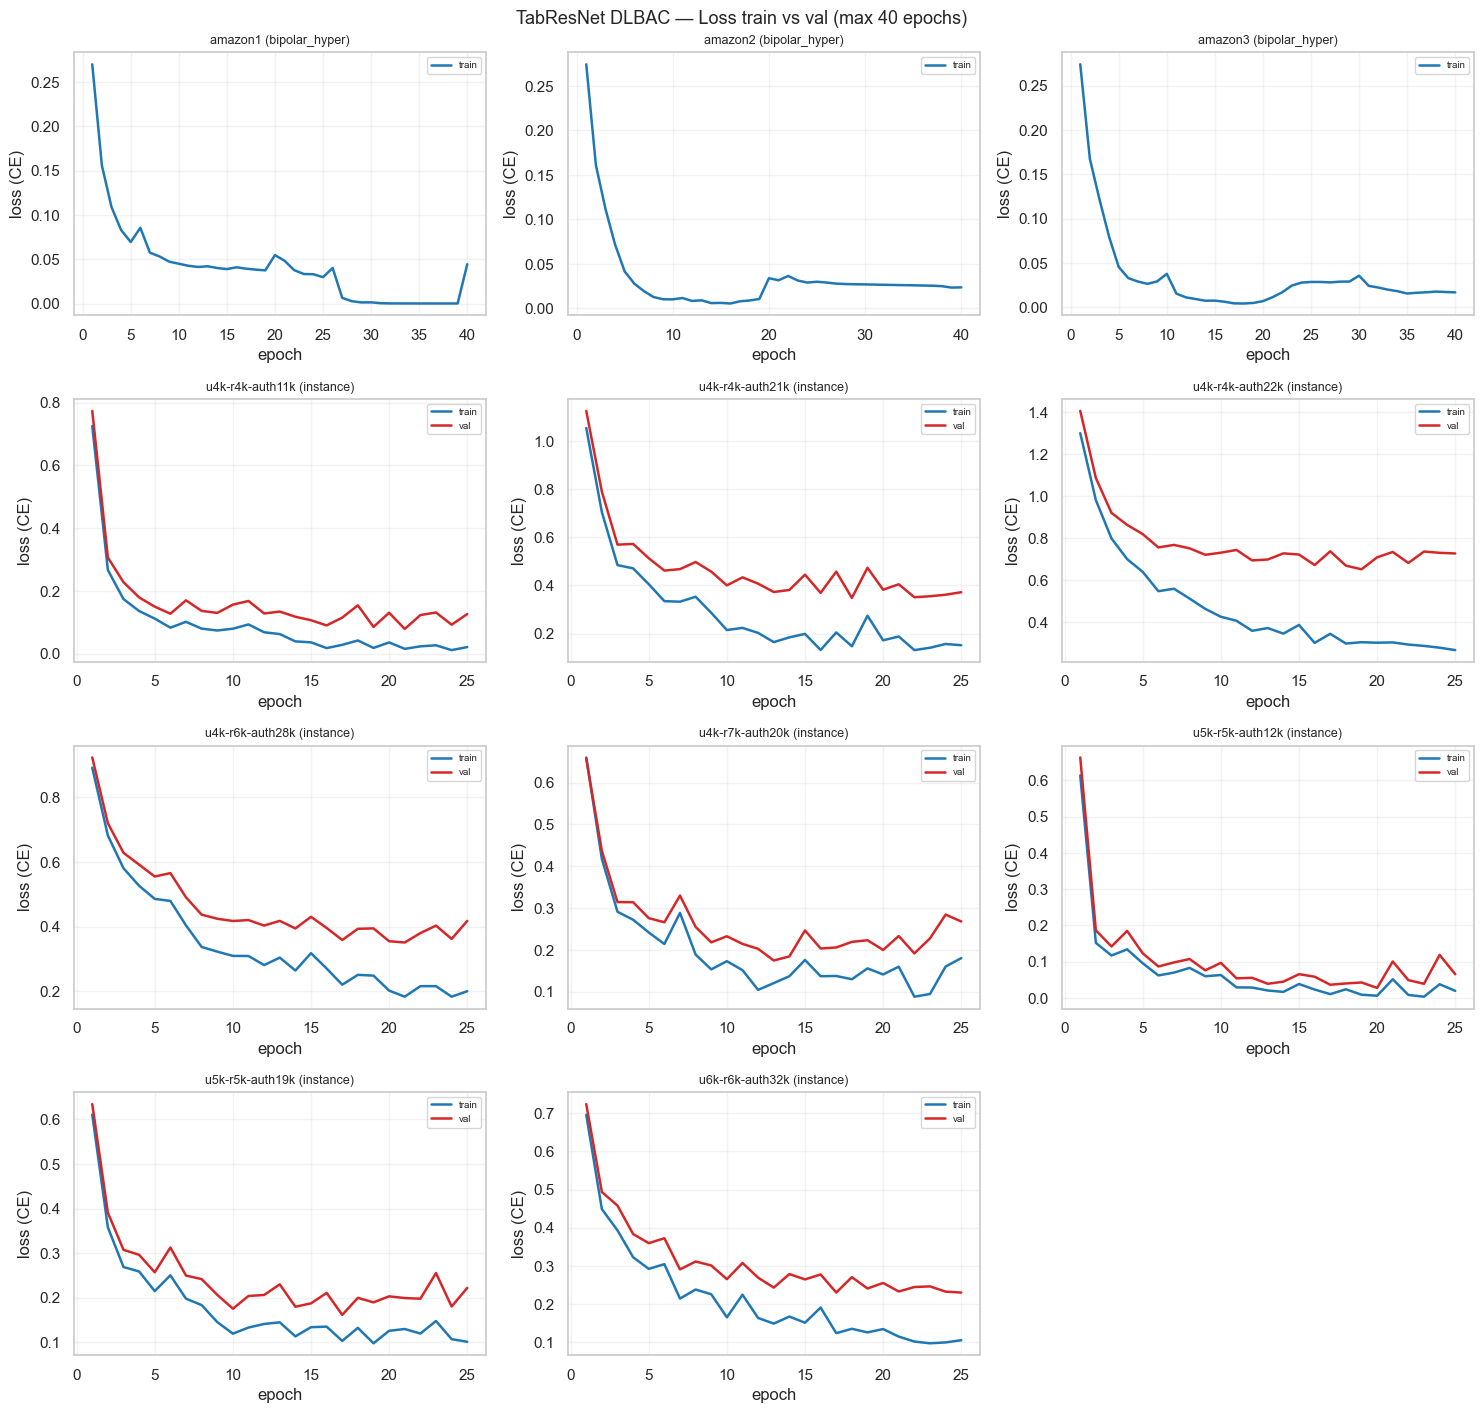

Figure sauvegardée : D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\tabresnet_dlbac\learning_curves_acc.png


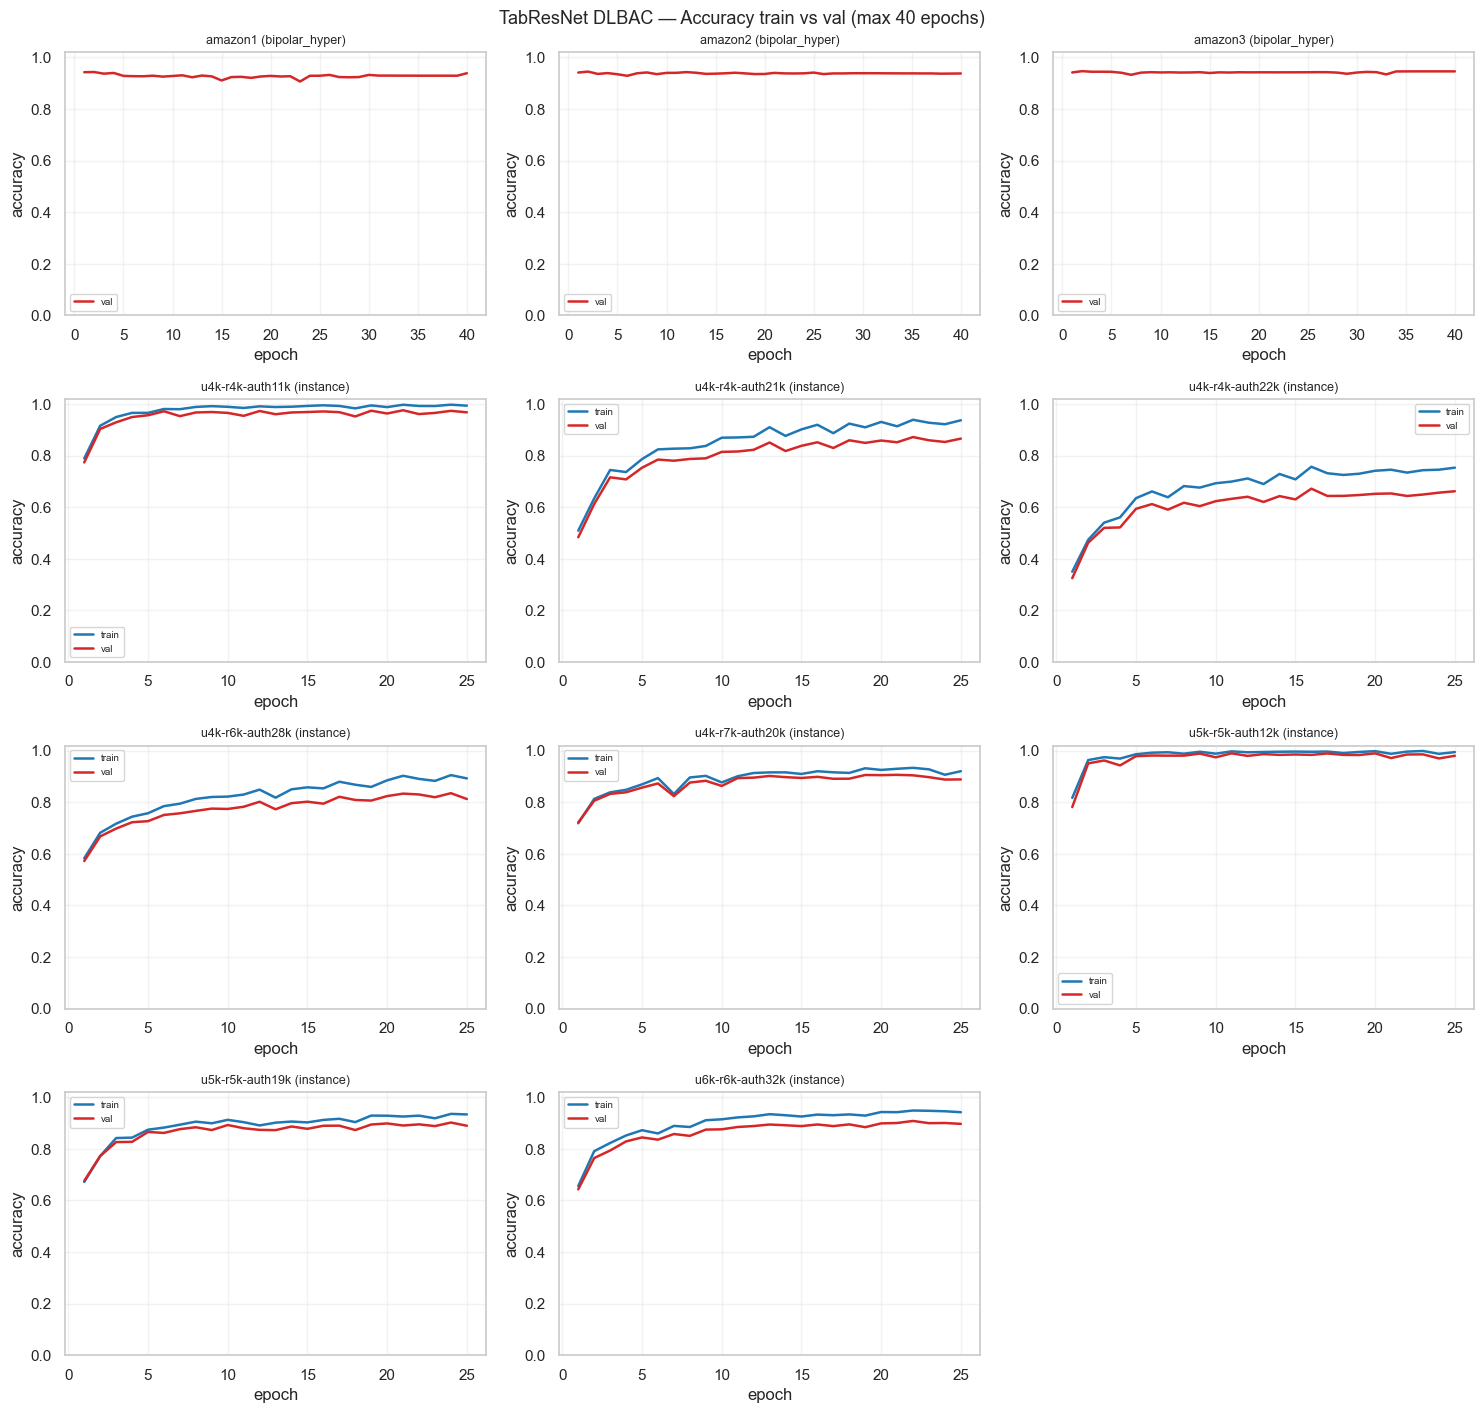

In [5]:
rows_by_name = {r["dataset"]: r for r in rows}
plot_all_learning_curves(histories, rows_by_name)

Figure sauvegardée : D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\tabresnet_dlbac\learning_curves_overlay_acc.png


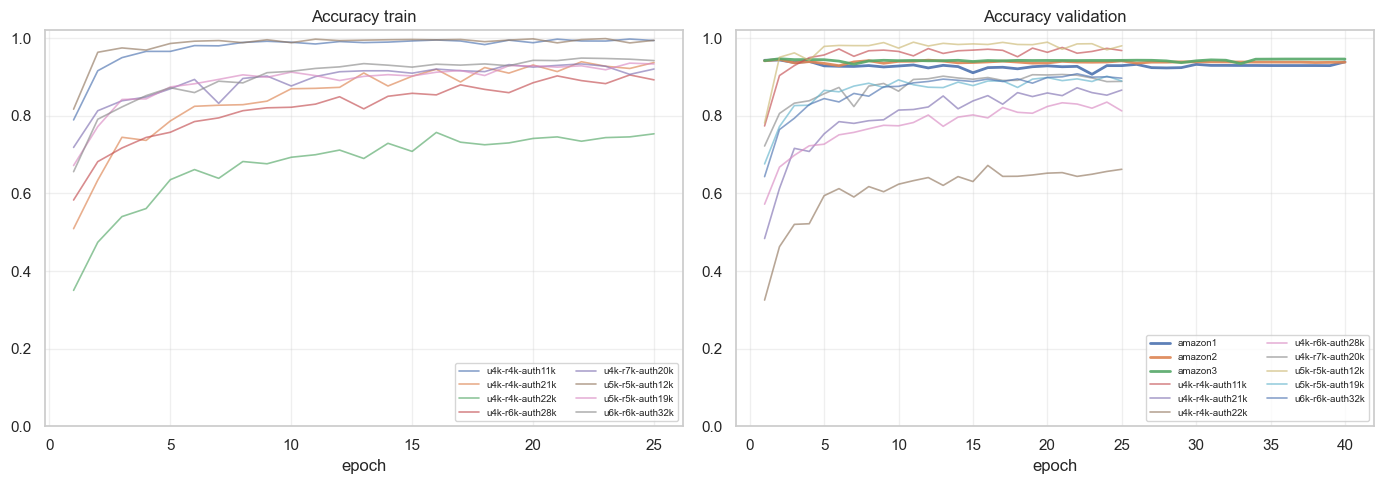

In [6]:
# Vue comparative : train vs val accuracy (tous les jeux)
if histories:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ds_name in [n for n in names if n in histories]:
        df = history_dataframe(ds_name, histories[ds_name])
        alpha = 0.9 if ds_name.startswith("amazon") else 0.65
        lw = 2.0 if ds_name.startswith("amazon") else 1.2
        if "train_accuracy" in df.columns:
            axes[0].plot(df["step"], df["train_accuracy"], alpha=alpha, linewidth=lw, label=ds_name)
        if "val_accuracy" in df.columns:
            axes[1].plot(df["step"], df["val_accuracy"], alpha=alpha, linewidth=lw, label=ds_name)

    axes[0].set_title("Accuracy train")
    axes[1].set_title("Accuracy validation")
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, ncol=2, loc="lower right")
    plt.tight_layout()
    cmp_path = RESULTS_DIR / "learning_curves_overlay_acc.png"
    fig.savefig(cmp_path, dpi=140, bbox_inches="tight")
    print(f"Figure sauvegardée : {cmp_path}")
    plt.show()
else:
    print("Pas d'historique pour la vue comparative.")

## Métriques détaillées (test set)

In [7]:
detailed_rows: list[dict] = []

for name in names:
    spec = ALL_SPECS[name]
    splits = build_onehot_splits(spec, val_size=0.2, random_state=42, use_cache=True)
    base = next(r for r in rows if r["dataset"] == name)

    try:
        trainer = load_trainer_from_checkpoint(name, splits, RESULTS_DIR, device=DEVICE)
        proba = trainer.predict_proba(splits.x_test)
        cls_metrics = compute_classification_metrics(
            splits.y_test, proba, class_names=splits.class_names
        )
        cf_native = trainer.evaluate(splits.x_test, splits.y_test, counterfactuals=True).get(
            "counterfactuals", {}
        )
    except FileNotFoundError as exc:
        print(f"[skip metrics] {name}: {exc}")
        continue

    cf_harm = {}
    if COMPUTE_CF_HARMONIZED:
        try:
            backend = load_cf_backend(name, splits, DEVICE)
            cf_harm = {
                "random_target": eval_random_target(
                    backend, splits.x_test, splits.y_test,
                    max_samples=MAX_CF_SAMPLES, seed=42,
                ),
                "all_targets": eval_all_targets(
                    backend, splits.x_test, splits.y_test,
                    max_samples=MAX_CF_SAMPLES, seed=42,
                ),
            }
        except Exception as exc:
            print(f"[warn CF harmonized] {name}: {exc}")

    is_amazon = name.startswith("amazon")
    row = {
        "dataset": name,
        "kind": "real_world" if is_amazon else "synthetic",
        "mode": base["mode"],
        "num_features": base["num_features"],
        "num_classes": base["num_classes"],
        "n_rules": base.get("n_rules_exported", 0),
        "best_val_accuracy": base.get("best_val_accuracy"),
        "best_val_auroc": base.get("best_val_auroc"),
        "test_accuracy": cls_metrics["accuracy"],
        "test_balanced_accuracy": cls_metrics["balanced_accuracy"],
        "test_auroc": cls_metrics["auroc"],
        "test_f1_macro": cls_metrics["f1_macro"],
        "test_f1_micro": cls_metrics["f1_micro"],
        "test_f1_weighted": cls_metrics["f1_weighted"],
        "test_precision_macro": cls_metrics["precision_macro"],
        "test_recall_macro": cls_metrics["recall_macro"],
        "test_log_loss": cls_metrics["log_loss"],
        "cf_validity_native": cf_native.get("validity_cf", np.nan),
        "cf_flips_native": cf_native.get("changed_bits_mean", np.nan),
        "cf_l1_native": cf_native.get("proximity_l1_cont_mean", cf_native.get("proximity_l1_mean", np.nan)),
        "cf_validity_random": cf_harm.get("random_target", {}).get("validity", np.nan),
        "cf_validity_all_targets": cf_harm.get("all_targets", {}).get("validity", np.nan),
        "cf_flips_harmonized": cf_harm.get("random_target", {}).get("changed_bits_mean", np.nan),
        "acceptable": base.get("acceptable", False),
        "threshold_auroc": 0.72 if is_amazon else 0.88,
        "_classification_report": cls_metrics["classification_report"],
        "_confusion_matrix": cls_metrics["confusion_matrix"],
    }
    if "deny_f1" in cls_metrics:
        row["deny_f1"] = cls_metrics["deny_f1"]
        row["grant_f1"] = cls_metrics["grant_f1"]
    detailed_rows.append(row)

df = pd.DataFrame(detailed_rows)
display_cols = [
    "dataset", "kind", "mode", "test_auroc", "test_accuracy", "test_balanced_accuracy",
    "test_f1_macro", "test_log_loss", "cf_validity_native", "cf_validity_random",
    "cf_validity_all_targets", "n_rules", "acceptable",
]
df[display_cols].sort_values("dataset").style.background_gradient(subset=["test_auroc"], cmap="Greens")

,dataset,kind,mode,test_auroc,test_accuracy,test_balanced_accuracy,test_f1_macro,test_log_loss,cf_validity_native,cf_validity_random,cf_validity_all_targets,n_rules,acceptable
0,amazon1,real_world,bipolar_hyper,0.857281,0.945674,0.618521,0.661008,0.167368,1.000000,1.000000,1.000000,48,True
1,amazon2,real_world,bipolar_hyper,0.827393,0.946284,0.586910,0.623914,0.173678,1.000000,1.000000,1.000000,48,True
2,amazon3,real_world,bipolar_hyper,0.828074,0.946589,0.590602,0.630435,0.176332,1.000000,1.000000,1.000000,48,True
3,u4k-r4k-auth11k,synthetic,instance,0.999472,0.973540,0.971798,0.972414,0.097510,0.060189,0.070000,0.060167,128,True
4,u4k-r4k-auth21k,synthetic,instance,0.994009,0.867223,0.881635,0.865010,0.395727,0.044339,0.052500,0.047000,128,True
5,u4k-r4k-auth22k,synthetic,instance,0.977007,0.660762,0.767578,0.709410,0.757292,0.060599,0.068750,0.059833,128,True
6,u4k-r6k-auth28k,synthetic,instance,0.990400,0.833565,0.878900,0.860769,0.483833,0.054319,0.065000,0.055917,128,True
7,u4k-r7k-auth20k,synthetic,instance,0.994362,0.890914,0.931910,0.918426,0.333065,0.012631,0.068750,0.012000,128,True
8,u5k-r5k-auth12k,synthetic,instance,0.999898,0.991332,0.992829,0.992218,0.051605,0.044313,0.068750,0.045583,128,True
9,u5k-r5k-auth19k,synthetic,instance,0.995573,0.901715,0.950065,0.909830,0.316465,0.044092,0.071250,0.043583,128,True


## Tableau récapitulatif & export CSV

In [8]:
export_df = df.drop(columns=[c for c in df.columns if c.startswith("_")], errors="ignore")
csv_path = RESULTS_DIR / "metrics_all_datasets.csv"
export_df.to_csv(csv_path, index=False)
print(f"Export: {csv_path}")
export_df.round(4)

Export: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\tabresnet_dlbac\metrics_all_datasets.csv


,dataset,kind,mode,num_features,num_classes,n_rules,best_val_accuracy,best_val_auroc,test_accuracy,test_balanced_accuracy,...,cf_validity_native,cf_flips_native,cf_l1_native,cf_validity_random,cf_validity_all_targets,cf_flips_harmonized,acceptable,threshold_auroc,deny_f1,grant_f1
0,amazon1,real_world,bipolar_hyper,14419,2,48,0.9437,0.8296,0.9457,0.6185,...,1.0000,7.3128,5.4614,1.0000,1.0000,7.2662,True,0.72,0.3504,0.9717
1,amazon2,real_world,bipolar_hyper,9476,2,48,0.9453,0.8143,0.9463,0.5869,...,1.0000,13.5085,10.2909,1.0000,1.0000,13.3675,True,0.72,0.2757,0.9721
2,amazon3,real_world,bipolar_hyper,9124,2,48,0.9470,0.8547,0.9466,0.5906,...,1.0000,5.0593,5.0002,1.0000,1.0000,5.1112,True,0.72,0.2886,0.9723
3,u4k-r4k-auth11k,synthetic,instance,157,16,128,0.9761,0.9996,0.9735,0.9718,...,0.0602,81.0291,81.0291,0.0700,0.0602,80.9200,True,0.88,NaN,NaN
4,u4k-r4k-auth21k,synthetic,instance,146,16,128,0.8722,0.9943,0.8672,0.8816,...,0.0443,73.9398,73.9397,0.0525,0.0470,73.9975,True,0.88,NaN,NaN
5,u4k-r4k-auth22k,synthetic,instance,133,16,128,0.6721,0.9756,0.6608,0.7676,...,0.0606,65.7061,65.7060,0.0688,0.0598,65.6388,True,0.88,NaN,NaN
6,u4k-r6k-auth28k,synthetic,instance,145,16,128,0.8353,0.9907,0.8336,0.8789,...,0.0543,66.4814,66.4813,0.0650,0.0559,66.4012,True,0.88,NaN,NaN
7,u4k-r7k-auth20k,synthetic,instance,152,16,128,0.9064,0.9953,0.8909,0.9319,...,0.0126,70.2365,70.2364,0.0688,0.0120,70.1775,True,0.88,NaN,NaN
8,u5k-r5k-auth12k,synthetic,instance,170,16,128,0.9897,0.9998,0.9913,0.9928,...,0.0443,95.2824,95.2822,0.0688,0.0456,95.3550,True,0.88,NaN,NaN
9,u5k-r5k-auth19k,synthetic,instance,164,16,128,0.9021,0.9960,0.9017,0.9501,...,0.0441,84.5954,84.5954,0.0712,0.0436,84.5512,True,0.88,NaN,NaN


## Visualisations — performance globale

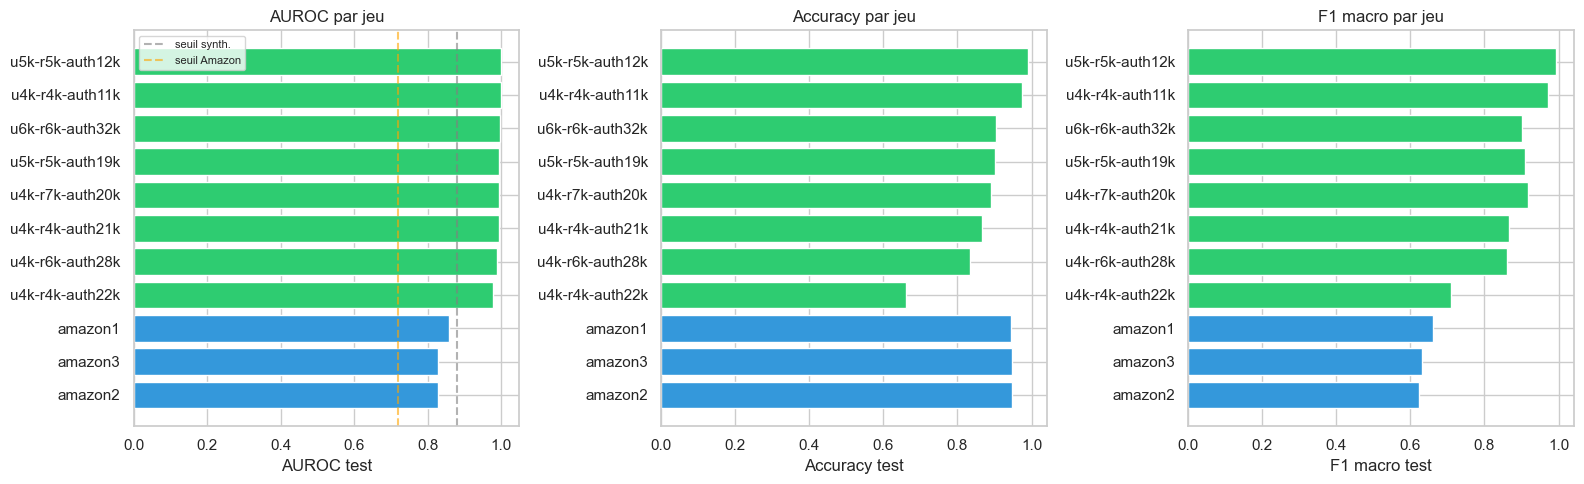

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_df = df.sort_values("test_auroc", ascending=True)
colors = plot_df["kind"].map({"synthetic": "#2ecc71", "real_world": "#3498db"})

axes[0].barh(plot_df["dataset"], plot_df["test_auroc"], color=colors)
axes[0].axvline(0.88, color="gray", ls="--", alpha=0.6, label="seuil synth.")
axes[0].axvline(0.72, color="orange", ls="--", alpha=0.6, label="seuil Amazon")
axes[0].set_xlabel("AUROC test")
axes[0].set_title("AUROC par jeu")
axes[0].legend(fontsize=8)

axes[1].barh(plot_df["dataset"], plot_df["test_accuracy"], color=colors)
axes[1].set_xlabel("Accuracy test")
axes[1].set_title("Accuracy par jeu")

axes[2].barh(plot_df["dataset"], plot_df["test_f1_macro"], color=colors)
axes[2].set_xlabel("F1 macro test")
axes[2].set_title("F1 macro par jeu")

plt.tight_layout()
plt.show()

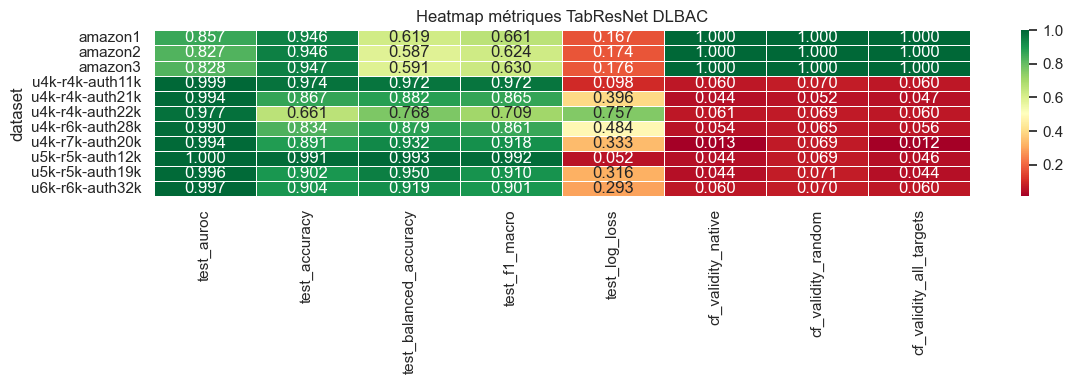

In [10]:
metric_cols = [
    "test_auroc", "test_accuracy", "test_balanced_accuracy",
    "test_f1_macro", "test_log_loss",
    "cf_validity_native", "cf_validity_random", "cf_validity_all_targets",
]
heat = df.set_index("dataset")[metric_cols].astype(float)
plt.figure(figsize=(12, max(4, 0.35 * len(heat))))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="RdYlGn", linewidths=0.5)
plt.title("Heatmap métriques TabResNet DLBAC")
plt.tight_layout()
plt.show()

## Contrefactuels — comparaison protocoles

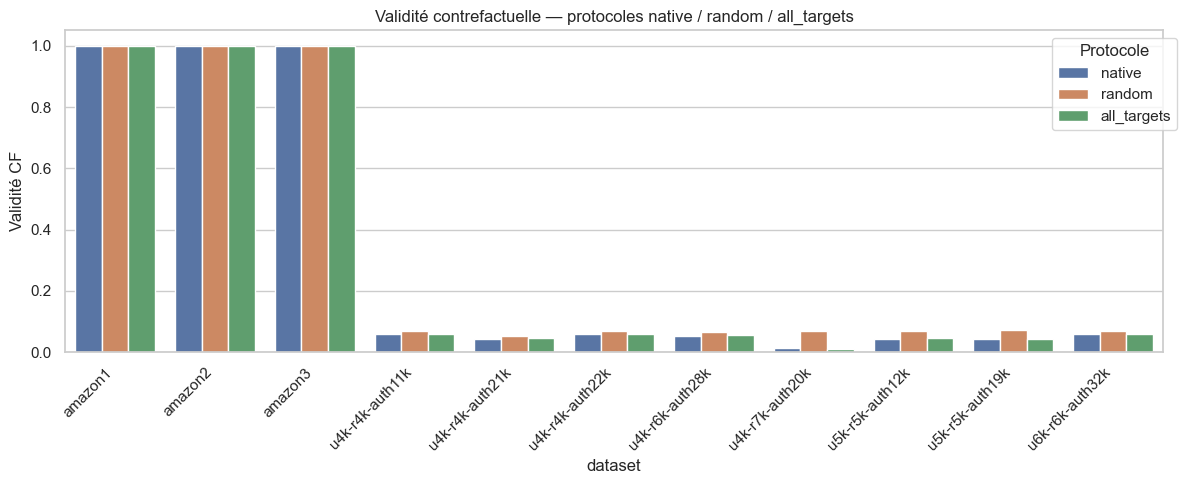

In [ ]:
cf_df = df[[
    "dataset", "mode",
    "cf_validity_native", "cf_validity_random", "cf_validity_all_targets",
    "cf_flips_native", "cf_flips_harmonized",
]].melt(
    id_vars=["dataset", "mode"],
    value_vars=["cf_validity_native", "cf_validity_random", "cf_validity_all_targets"],
    var_name="protocole", value_name="validite",
)
cf_df["protocole"] = cf_df["protocole"].str.replace("cf_validity_", "")

plt.figure(figsize=(12, 5))
sns.barplot(data=cf_df, x="dataset", y="validite", hue="protocole")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Validité CF")
plt.title("Validité contrefactuelle — protocoles native / random / all_targets")
plt.legend(title="Protocole", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## Synthétiques vs Amazon — agrégats

In [12]:
agg = export_df.groupby("kind").agg(
    n=("dataset", "count"),
    auroc_mean=("test_auroc", "mean"),
    auroc_min=("test_auroc", "min"),
    acc_mean=("test_accuracy", "mean"),
    f1_macro_mean=("test_f1_macro", "mean"),
    cf_random_mean=("cf_validity_random", "mean"),
    pass_rate=("acceptable", "mean"),
).round(4)
agg

,n,auroc_mean,auroc_min,acc_mean,f1_macro_mean,cf_random_mean,pass_rate
kind,,,,,,,
real_world,3,0.8376,0.8274,0.9462,0.6385,1.0000,1.0
synthetic,8,0.9935,0.9770,0.8778,0.8912,0.0669,1.0


## Zoom — matrice de confusion & rapport par classe

Choisir un jeu dans `FOCUS_DATASET`.

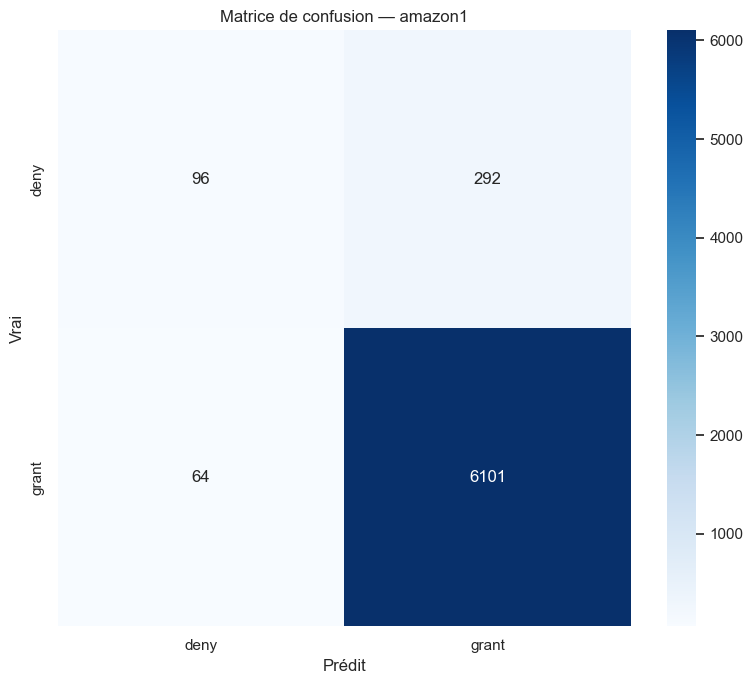

,precision,recall,f1-score,support
deny,0.6000,0.2474,0.3504,388.0
grant,0.9543,0.9896,0.9717,6165.0


In [13]:
FOCUS_DATASET = names[0] if names else "u4k-r4k-auth11k"

focus = next(r for r in detailed_rows if r["dataset"] == FOCUS_DATASET)
cm = np.array(focus["_confusion_matrix"])
splits = build_onehot_splits(ALL_SPECS[FOCUS_DATASET], use_cache=True)
class_names = splits.class_names

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names if len(class_names) <= 20 else False,
    yticklabels=class_names if len(class_names) <= 20 else False,
    ax=ax,
)
ax.set_xlabel("Prédit")
ax.set_ylabel("Vrai")
ax.set_title(f"Matrice de confusion — {FOCUS_DATASET}")
plt.tight_layout()
plt.show()

report = focus["_classification_report"]
per_class = {k: v for k, v in report.items() if k in class_names}
pd.DataFrame(per_class).T[["precision", "recall", "f1-score", "support"]].round(4)

## Règles métier & exemple contrefactuel

In [ ]:
base_row = next(r for r in rows if r["dataset"] == FOCUS_DATASET)

print(f"=== {FOCUS_DATASET} — mode {base_row['mode']} ===\n")
print("Top 5 règles exportées:")
for i, rule in enumerate(base_row.get("rules_top5", [])[:5], 1):
    print(f"  {i}. {rule['text']}")

ex_cf = base_row.get("example_counterfactual")
if ex_cf:
    print("\nExemple contrefactuel:")
    print(f"  y_true={ex_cf.get('y_true')} | pred_orig={ex_cf.get('y_pred_orig', ex_cf.get('y_pred_orig_name'))}")
    print(f"  cible={ex_cf.get('y_target', ex_cf.get('y_target_name'))} | pred_cf={ex_cf.get('y_pred_cf', ex_cf.get('y_pred_cf_name'))}")
    print(f"  valide={ex_cf.get('valid')} | n_modifs={ex_cf.get('n_flips', ex_cf.get('n_changes', '?'))}")
    changes = ex_cf.get("flips") or ex_cf.get("changes") or []
    for c in changes[:8]:
        if "delta" in c:
            print(f"    {c['feature']}: {c['from']:.3f} -> {c['to']:.3f}")
        else:
            print(f"    {c['feature']}: {c['from']} -> {c['to']}")
else:
    print("\nAucun exemple CF trouvé dans le cache JSON.")

=== amazon1 — mode bipolar_hyper ===

Top 5 règles exportées:
  1. IF z_15=+1 AND z_46=+1 AND z_36=+1 AND z_52=+1 THEN grant (score=0.521)
  2. IF z_27=+1 AND z_47=-1 AND z_20=-1 AND z_17=-1 THEN grant (score=0.516)
  3. IF z_27=+1 AND z_62=-1 AND z_25=+1 AND z_7=-1 THEN grant (score=0.514)
  4. IF z_27=+1 AND z_25=+1 AND z_59=+1 AND z_1=+1 THEN grant (score=0.514)
  5. IF z_27=+1 AND z_57=-1 AND z_5=-1 AND z_23=-1 THEN grant (score=0.513)

Exemple contrefactuel:
  y_true=1 | pred_orig=1
  cible=0 | pred_cf=0
  valide=True | n_modifs=8
    oh_6725: -1 -> 1
    oh_10182: -1 -> 1
    oh_10286: -1 -> 1
    oh_11661: -1 -> 1
    oh_12410: -1 -> 1
    oh_13241: -1 -> 1
    oh_13292: -1 -> 1
    oh_13927: -1 -> 1


## F1 par classe (jeux synthétiques)

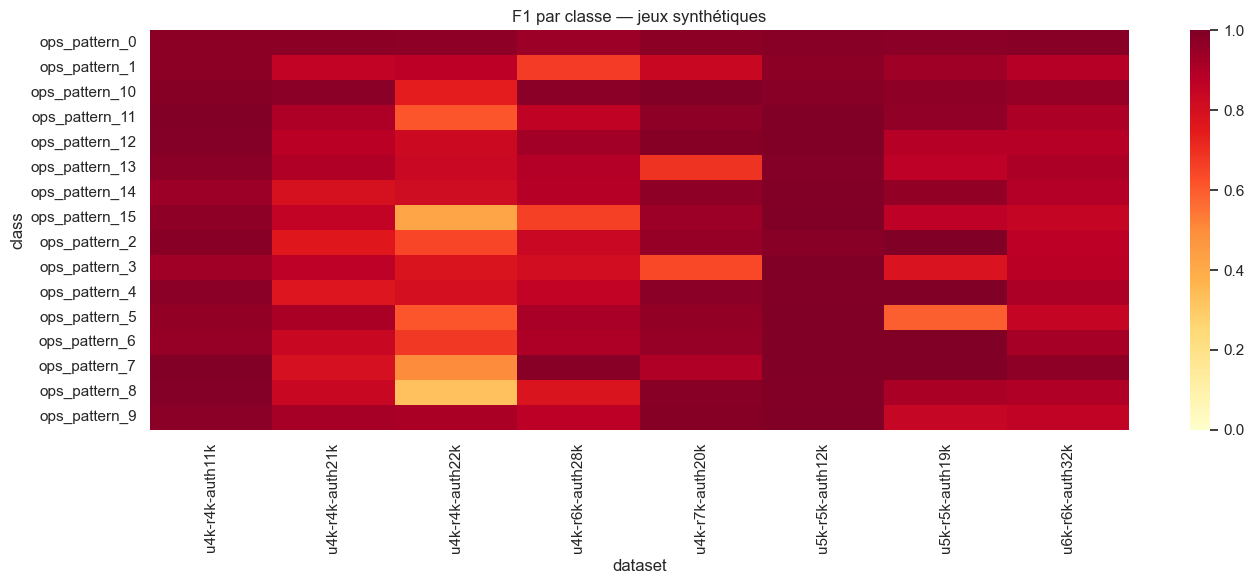

In [ ]:
syn_rows = [r for r in detailed_rows if r["kind"] == "synthetic"]
if syn_rows:
    f1_records = []
    for r in syn_rows:
        report = r["_classification_report"]
        for cls, stats in report.items():
            if isinstance(stats, dict) and "f1-score" in stats:
                if cls not in ("accuracy", "macro avg", "weighted avg"):
                    f1_records.append({"dataset": r["dataset"], "class": cls, "f1": stats["f1-score"]})
    f1_df = pd.DataFrame(f1_records)
    pivot = f1_df.pivot(index="class", columns="dataset", values="f1")
    plt.figure(figsize=(14, max(6, 0.25 * len(pivot))))
    sns.heatmap(pivot.astype(float), annot=False, cmap="YlOrRd", vmin=0, vmax=1)
    plt.title("F1 par classe — jeux synthétiques")
    plt.tight_layout()
    plt.show()
else:
    print("Pas de jeux synthétiques dans la sélection.")